# FinCast — Dataset Analysis
Produces charts, tables, and CSVs for human review and LLM/agent consumption.

In [1]:
import os, json, yaml, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

cwd = Path.cwd()
if (cwd / 'create_data' / 'gdelt_config.yaml').exists() and (cwd / 'data' / 'raw').exists():
    BASE_DIR = cwd
elif (cwd / 'news_scraper' / 'create_data' / 'gdelt_config.yaml').exists() and (cwd / 'news_scraper' / 'data' / 'raw').exists():
    BASE_DIR = cwd / 'news_scraper'
elif (cwd / '..' / 'create_data' / 'gdelt_config.yaml').resolve().exists() and (cwd / '..' / 'data' / 'raw').resolve().exists():
    BASE_DIR = (cwd / '..').resolve()
elif (cwd / '..' / '..' / 'create_data' / 'gdelt_config.yaml').resolve().exists() and (cwd / '..' / '..' / 'data' / 'raw').resolve().exists():
    BASE_DIR = (cwd / '..' / '..').resolve()
else:
    raise FileNotFoundError(f'Could not locate gdelt_config.yaml from cwd {cwd}')

DATA_DIR = str((BASE_DIR / 'data' / 'raw').resolve())
CONFIG_PATH = str((BASE_DIR / 'create_data' / 'gdelt_config.yaml').resolve())
ANALYSIS_DIR = str((BASE_DIR / 'analysis').resolve())
os.makedirs(ANALYSIS_DIR, exist_ok=True)

def save_csv(df, name):
    path = os.path.join(ANALYSIS_DIR, name)
    df.to_csv(path)
    print(f'  Saved: {path}')

print('Libraries loaded')
print('cwd=', cwd)
print('DATA_DIR=', DATA_DIR)
print('CONFIG_PATH=', CONFIG_PATH)
print('ANALYSIS_DIR=', ANALYSIS_DIR)


Libraries loaded
cwd= c:\work\PratyushMishraGitHub\news_analysis\news_scraper\analyze_data
DATA_DIR= C:\work\PratyushMishraGitHub\news_analysis\news_scraper\data\raw
CONFIG_PATH= C:\work\PratyushMishraGitHub\news_analysis\news_scraper\create_data\gdelt_config.yaml
ANALYSIS_DIR= C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis


In [2]:
with open(CONFIG_PATH, 'r') as fh:
    cfg = yaml.safe_load(fh)
t = cfg.get('tickers', {})
ALL_TICKERS = {}
ALL_TICKERS.update({k: v for k, v in (t.get('company_queries', {}) or {}).items() if v})
ALL_TICKERS.update({k: v for k, v in (t.get('plain_names',    {}) or {}).items() if v})
ALL_TICKERS.update({k: v for k, v in (t.get('sector_queries', {}) or {}).items() if v})
BENCHMARKS      = t.get('benchmarks', {})
COMPANY_QUERIES = set((t.get('company_queries', {}) or {}).keys()) | \
                  set((t.get('plain_names',    {}) or {}).keys())
ETF_LABELS = {
    'SOXX':'Semiconductor','SKYY':'Cloud','DRIV':'EV','XLV':'Healthcare',
    'XLF':'Finance','BOTZ':'AI/Robotics','USO':'Oil','TLT':'Bonds',
    'UUP':'Dollar','XLK':'Tech ETF','CIBR':'Cybersec','SPY':'S&P500','QQQ':'Nasdaq'
}
print(f'Loaded {len(ALL_TICKERS)} ticker mappings')

Loaded 35 ticker mappings


In [3]:
def load_articles(data_dir):
    rows = []
    processed = 0
    for root, _, files in os.walk(data_dir):
        for f in files:
            if not f.endswith('.json'):
                continue
            processed += 1
            if processed % 500 == 0:
                print(f'Loading articles... processed {processed} JSON files so far')
            with open(os.path.join(root, f), 'r', encoding='utf-8') as fh:
                meta = json.load(fh)
            gdelt_query = meta.get('gdelt_query', '')
            ticker      = ALL_TICKERS.get(gdelt_query)
            if not ticker:
                continue
            pc           = meta.get('price_changes', {})
            ticker_pc    = pc.get(gdelt_query, {})
            benchmark    = BENCHMARKS.get(ticker, 'SPY')
            benchmark_pc = pc.get(benchmark, {})
            date_str     = (meta.get('publish_date') or meta.get('scrape_date',''))[:10]
            rows.append({
                'date':               pd.to_datetime(date_str, errors='coerce'),
                'site':               meta.get('site',''),
                'gdelt_query':        gdelt_query,
                'ticker':             ticker,
                'benchmark':          benchmark,
                'category':           'company' if gdelt_query in COMPANY_QUERIES else 'sector/macro',
                'title':              meta.get('title',''),
                'summary':            meta.get('summary',''),
                'sentiment':          meta.get('sentiment'),
                'word_count':         meta.get('word_count', 0),
                'relevance':          meta.get('relevance', 1),
                'direction':          meta.get('direction', ''),
                'base_price':         ticker_pc.get('base_price'),
                'next_price':         ticker_pc.get('next_price'),
                'change_1d':          ticker_pc.get('change_1d'),
                'trailing_vol_pct':   ticker_pc.get('trailing_vol_pct'),
                'bucket_1d':          ticker_pc.get('bucket_1d'),
                'magnitude':          ticker_pc.get('magnitude'),
                'bm_change_1d':       benchmark_pc.get('change_1d'),
                'bm_trailing_vol_pct':benchmark_pc.get('trailing_vol_pct'),
                'bm_bucket_1d':       benchmark_pc.get('bucket_1d'),
                'url':                meta.get('url',''),
            })
    print(f'Finished loading {processed} JSON files from {data_dir}')
    return pd.DataFrame(rows)


df = load_articles(DATA_DIR).sort_values('date').reset_index(drop=True)
# Filter out low-relevance articles to focus on more impactful news
if not df.empty:
    df = df[df['relevance'] > 1]
# z-score of the day's move relative to the ticker's own trailing volatility
# (same quantity fetch_prices.py uses to assign bucket_1d) — handy for
# correlation work below since it's instrument-relative, unlike change_1d.
df['z_score'] = df['change_1d'] / df['trailing_vol_pct'].where(df['trailing_vol_pct'] > 0)
print(f'Loaded {len(df):,} articles')
min_date = df['date'].min().date() if not df['date'].isna().all() else None
max_date = df['date'].max().date() if not df['date'].isna().all() else None
print(f"Date range:      {min_date} to {max_date}")
print(f'Unique tickers:  {df["ticker"].nunique()}')
print(f'With price data: {df["bucket_1d"].notna().sum():,}')
print(f'With trailing_vol_pct: {df["trailing_vol_pct"].notna().sum():,}')


Loading articles... processed 500 JSON files so far
Loading articles... processed 1000 JSON files so far
Loading articles... processed 1500 JSON files so far
Loading articles... processed 2000 JSON files so far
Loading articles... processed 2500 JSON files so far
Loading articles... processed 3000 JSON files so far
Loading articles... processed 3500 JSON files so far
Loading articles... processed 4000 JSON files so far
Loading articles... processed 4500 JSON files so far
Loading articles... processed 5000 JSON files so far
Loading articles... processed 5500 JSON files so far
Loading articles... processed 6000 JSON files so far
Loading articles... processed 6500 JSON files so far
Loading articles... processed 7000 JSON files so far
Loading articles... processed 7500 JSON files so far
Loading articles... processed 8000 JSON files so far
Loading articles... processed 8500 JSON files so far
Loading articles... processed 9000 JSON files so far
Loading articles... processed 9500 JSON files s

## 1 — Article & Ticker Distribution

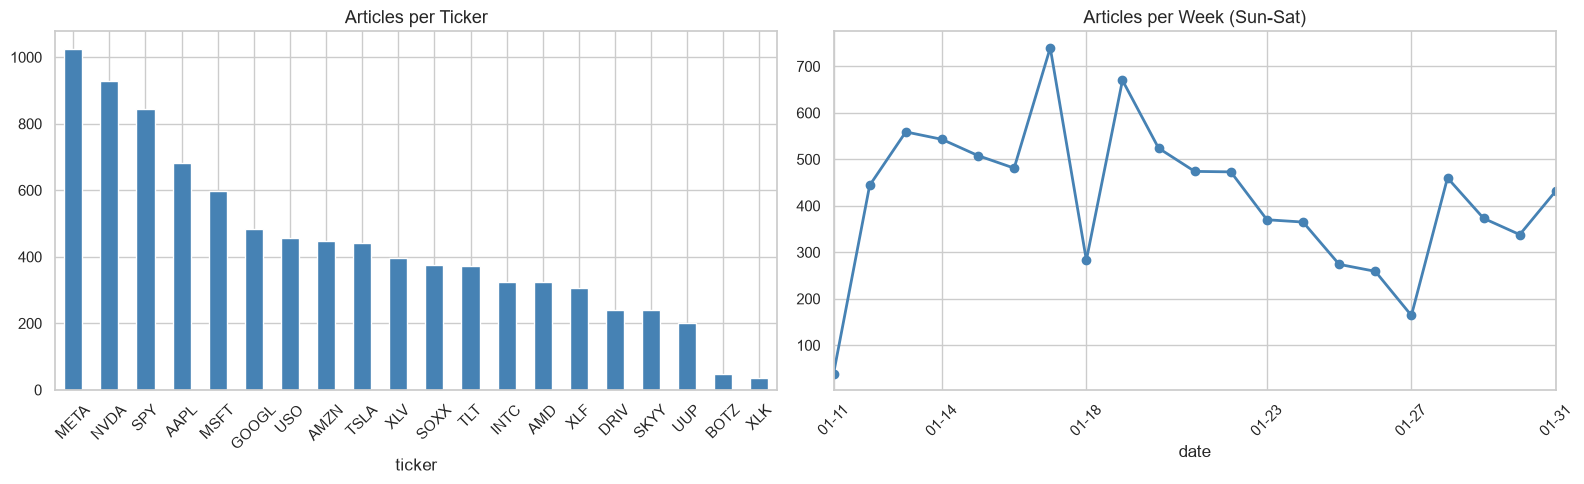

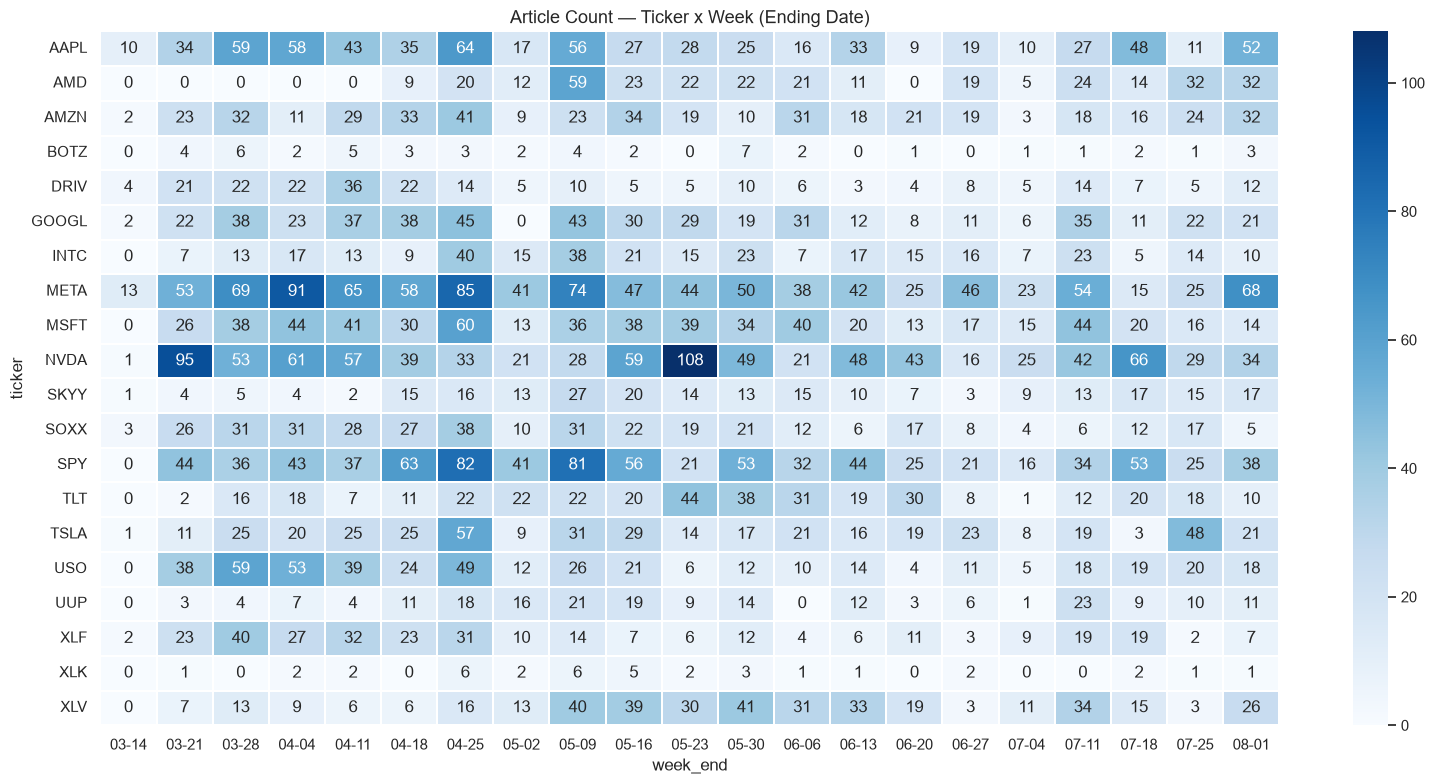


--- Articles per Ticker ---


,count,pct
ticker,,
META,1026,11.7
NVDA,928,10.6
SPY,845,9.6
AAPL,681,7.8
MSFT,598,6.8
GOOGL,483,5.5
USO,458,5.2
AMZN,448,5.1
TSLA,442,5.0


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\dist_articles_per_ticker.csv

--- Articles per Week ---


,count
date,
2026-03-14 (Sat),39
2026-03-21 (Sat),444
2026-03-28 (Sat),559
2026-04-04 (Sat),543
2026-04-11 (Sat),508
2026-04-18 (Sat),481
2026-04-25 (Sat),740
2026-05-02 (Sat),283
2026-05-09 (Sat),670


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\dist_articles_per_week.csv
  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\dist_ticker_week_heatmap.csv


In [4]:
# Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ticker_counts = df['ticker'].value_counts()
ticker_counts.plot(kind='bar', ax=axes[0], color='steelblue',)
axes[0].set_title('Articles per Ticker')
axes[0].tick_params(axis='x', rotation=45)
weekly = df.set_index('date').resample('W-SAT').size()
weekly.plot(ax=axes[1], color='steelblue', linewidth=2, marker='o')
axes[1].set_title('Articles per Week (Sun-Sat)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout(); plt.show()

# Weekly pivot: group by week ending date
df_week = df.copy()
df_week['week_end'] = df_week['date'].dt.to_period('W-SAT').dt.end_time
week_labels = df_week['week_end'].dt.strftime('%m-%d')
pivot = df.pivot_table(index='ticker', columns=week_labels,
                       values='url', aggfunc='count', fill_value=0)
plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap='Blues', linewidths=0.3, annot=True, fmt='d')
plt.title('Article Count — Ticker x Week (Ending Date)')
plt.tight_layout(); plt.show()

# Tables
ticker_table = ticker_counts.rename('count').to_frame()
ticker_table['pct'] = (ticker_table['count'] / len(df) * 100).round(1)
print('\n--- Articles per Ticker ---')
display(ticker_table)
save_csv(ticker_table, 'dist_articles_per_ticker.csv')

weekly_table = weekly.rename('count').to_frame()
weekly_table.index = weekly_table.index.strftime('%Y-%m-%d (Sat)')
print('\n--- Articles per Week ---')
display(weekly_table)
save_csv(weekly_table, 'dist_articles_per_week.csv')
save_csv(pivot, 'dist_ticker_week_heatmap.csv')

## 2 — Sentiment Distribution

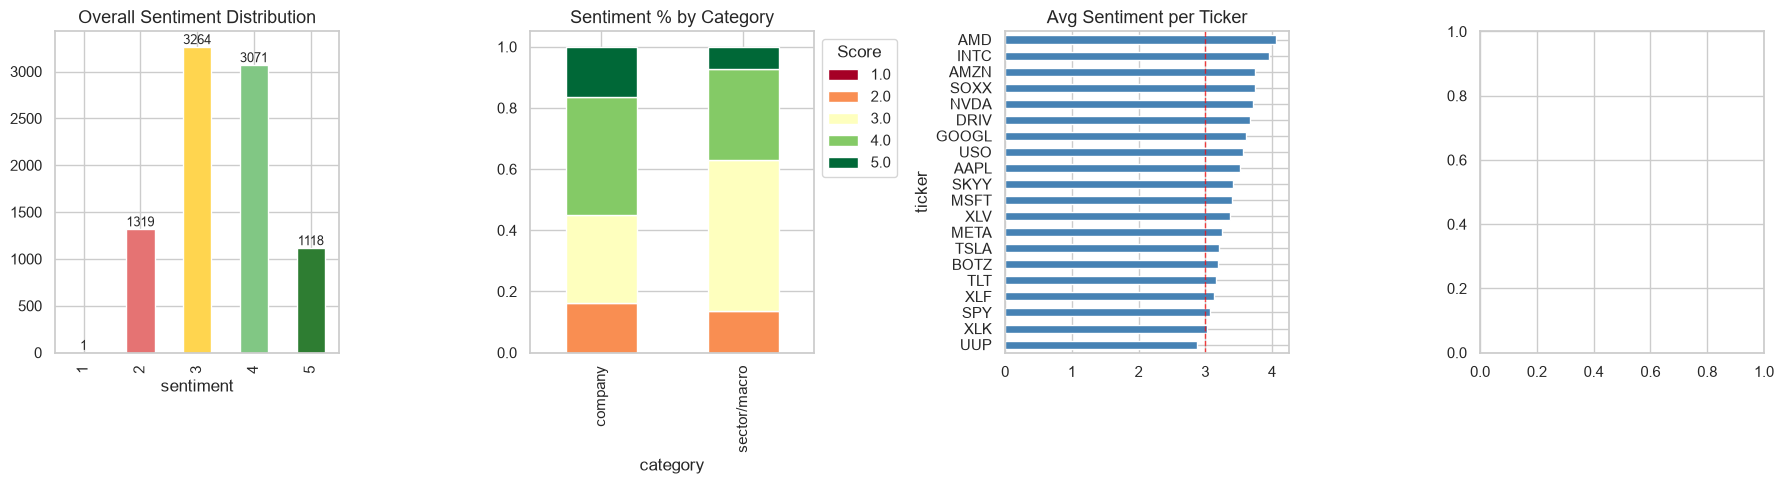

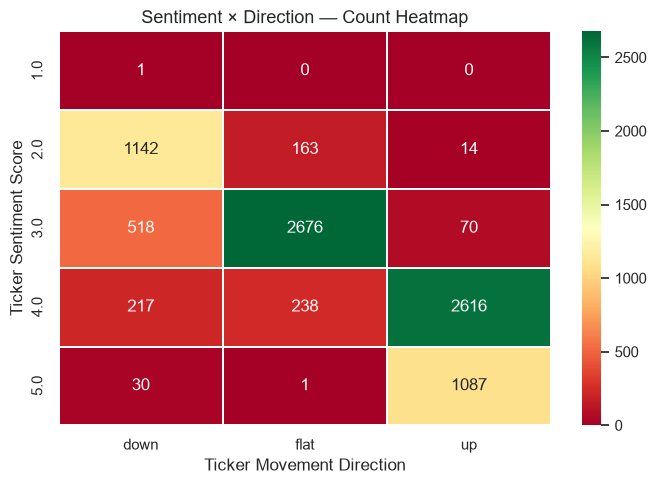


--- Sentiment Distribution ---


,count,pct
sentiment_score,,
1,1,0.0
2,1319,15.0
3,3264,37.2
4,3071,35.0
5,1118,12.7


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\dist_sentiment.csv

--- Sentiment Stats per Ticker ---


,count,mean,std,min,max
ticker,,,,,
AAPL,681,3.52,0.89,2.0,5.0
AMD,325,4.05,0.84,2.0,5.0
AMZN,448,3.75,0.93,2.0,5.0
BOTZ,49,3.18,0.60,2.0,4.0
DRIV,240,3.66,0.84,2.0,5.0
GOOGL,483,3.61,0.93,2.0,5.0
INTC,325,3.95,0.92,2.0,5.0
META,1026,3.25,0.96,1.0,5.0
MSFT,598,3.40,0.83,2.0,5.0


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\dist_sentiment_per_ticker.csv


In [5]:
colors = ['#d32f2f','#e57373','#ffd54f','#81c784','#2e7d32']
sent   = df['sentiment'].dropna().astype(int).value_counts().sort_index()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
sent.plot(kind='bar', ax=axes[0], color=colors)
# sentiment distribution (count)
axes[0].set_title('Overall Sentiment Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)
df.dropna(subset=['sentiment']).groupby('category')['sentiment'] \
  .value_counts(normalize=True).unstack() \
  .plot(kind='bar', ax=axes[1], colormap='RdYlGn', stacked=True)

axes[1].set_title('Sentiment % by Category')
axes[1].legend(title='Score', bbox_to_anchor=(1,1))
df.groupby('ticker')['sentiment'].mean().sort_values() \
  .plot(kind='barh', ax=axes[2], color='steelblue')

axes[2].axvline(3, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[2].set_title('Avg Sentiment per Ticker')
plt.tight_layout(); plt.show()

# Sentiment × Direction heatmap
axes[3].set_title('Sentiment × Direction Distribution')
sent_dir = (
    df.dropna(subset=['sentiment', 'direction'])
      .groupby(['sentiment', 'direction'])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(7, 5))
sns.heatmap(sent_dir, annot=True, fmt='d', cmap='RdYlGn', linewidths=0.3)
plt.title('Sentiment × Direction — Count Heatmap')
plt.xlabel('Ticker Movement Direction')
plt.ylabel('Ticker Sentiment Score')
plt.tight_layout()
plt.show()

# Tables
sent_table = pd.DataFrame({'count': sent, 'pct': (sent/sent.sum()*100).round(1)})
sent_table.index.name = 'sentiment_score'
print('\n--- Sentiment Distribution ---')
display(sent_table)
save_csv(sent_table, 'dist_sentiment.csv')

sent_ticker = df.dropna(subset=['sentiment']).groupby('ticker')['sentiment'].agg(
    count='count', mean='mean', std='std', min='min', max='max').round(2)
print('\n--- Sentiment Stats per Ticker ---')
display(sent_ticker)
save_csv(sent_ticker, 'dist_sentiment_per_ticker.csv')

flat_pct = sent.get(3,0)/sent.sum()*100
if flat_pct > 50:
    print(f'\n⚠ Neutral sentiment (3) = {flat_pct:.1f}% — consider more targeted queries')

## 3 — Price Bucket Distribution

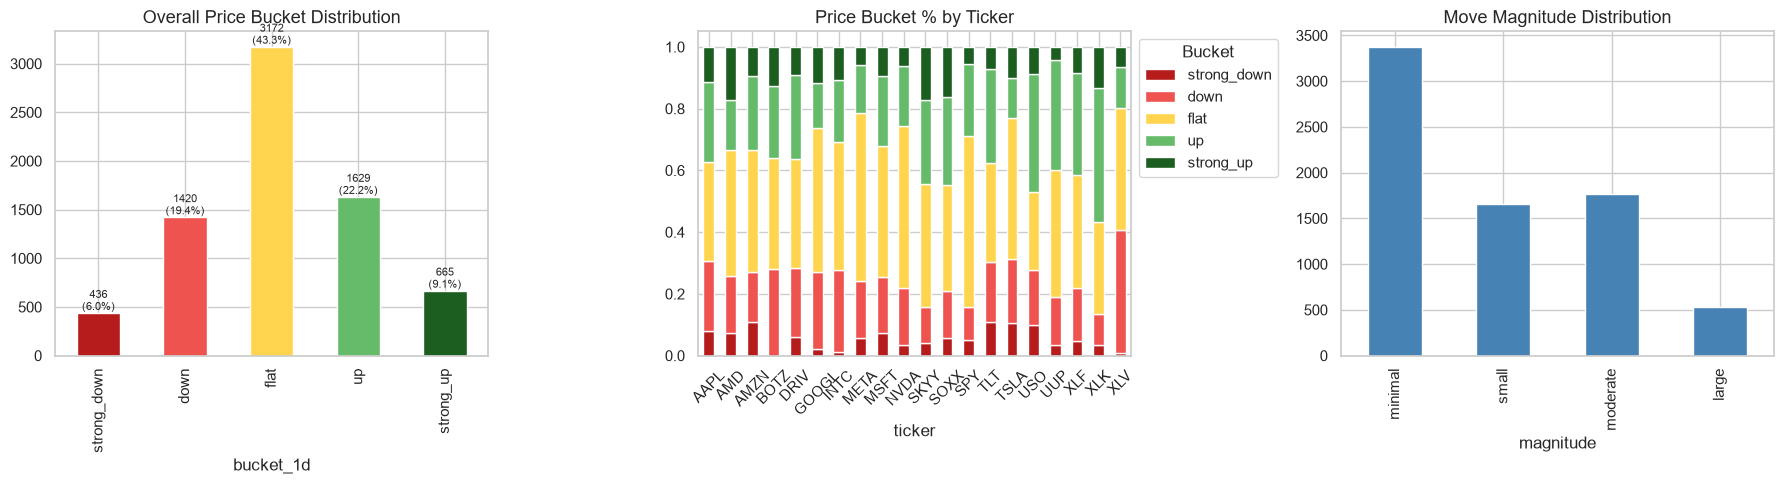


--- Price Bucket Distribution ---


,count,pct
bucket_1d,,
strong_down,436,6.0
down,1420,19.4
flat,3172,43.3
up,1629,22.2
strong_up,665,9.1


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\dist_price_buckets.csv

--- Price Bucket % per Ticker ---


,strong_down_pct,down_pct,flat_pct,up_pct,strong_up_pct,flat_flag
ticker,,,,,,
AAPL,7.9,22.9,32.0,25.9,11.3,OK
AMD,7.2,18.4,40.8,16.4,17.1,OK
AMZN,10.8,16.4,39.4,24.0,9.5,OK
BOTZ,NaN,28.2,35.9,23.1,12.8,OK
DRIV,6.2,22.3,35.4,26.9,9.2,OK
GOOGL,2.1,25.0,46.5,14.8,11.6,OK
INTC,1.0,26.8,41.2,20.3,10.7,OK
META,5.6,18.6,54.3,15.7,5.7,OK
MSFT,7.4,18.2,42.3,22.8,9.4,OK


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\dist_price_buckets_per_ticker.csv

--- Magnitude Distribution ---


,count,pct
magnitude,,
minimal,3374,46.1
small,1659,22.7
moderate,1762,24.1
large,527,7.2


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\dist_magnitude.csv


In [6]:
labeled       = df.dropna(subset=['bucket_1d'])
bucket_order  = ['strong_down','down','flat','up','strong_up']
colors_bucket = ['#b71c1c','#ef5350','#ffd54f','#66bb6a','#1b5e20']
bucket_counts = labeled['bucket_1d'].value_counts().reindex(bucket_order, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bucket_counts.plot(kind='bar', ax=axes[0], color=colors_bucket)
axes[0].set_title('Overall Price Bucket Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}\n({p.get_height()/len(labeled)*100:.1f}%)',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)
labeled.groupby('ticker')['bucket_1d'].value_counts(normalize=True).unstack() \
    .reindex(columns=bucket_order, fill_value=0) \
    .plot(kind='bar', stacked=True, ax=axes[1], color=colors_bucket)
axes[1].set_title('Price Bucket % by Ticker')
axes[1].legend(title='Bucket', bbox_to_anchor=(1,1))
axes[1].tick_params(axis='x', rotation=45)
mag_order = ['minimal','small','moderate','large']
labeled['magnitude'].value_counts().reindex(mag_order, fill_value=0) \
    .plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Move Magnitude Distribution')
plt.tight_layout(); plt.show()

# Tables
bucket_table = pd.DataFrame({
    'count': bucket_counts,
    'pct':   (bucket_counts/bucket_counts.sum()*100).round(1)
})
print('\n--- Price Bucket Distribution ---')
display(bucket_table)
save_csv(bucket_table, 'dist_price_buckets.csv')

bucket_ticker = labeled.groupby('ticker')['bucket_1d'] \
    .value_counts(normalize=True).unstack() \
    .reindex(columns=bucket_order, fill_value=0).mul(100).round(1)
bucket_ticker.columns = [f'{c}_pct' for c in bucket_ticker.columns]
bucket_ticker['flat_flag'] = bucket_ticker.get('flat_pct', pd.Series(dtype=float)).apply(
    lambda x: 'HIGH' if x > 70 else 'OK')
print('\n--- Price Bucket % per Ticker ---')
display(bucket_ticker)
save_csv(bucket_ticker, 'dist_price_buckets_per_ticker.csv')

mag_table = labeled['magnitude'].value_counts().reindex(mag_order, fill_value=0)
mag_df = pd.DataFrame({'count': mag_table, 'pct': (mag_table/mag_table.sum()*100).round(1)})
print('\n--- Magnitude Distribution ---')
display(mag_df)
save_csv(mag_df, 'dist_magnitude.csv')

## 4 — Sentiment vs Price Mismatch

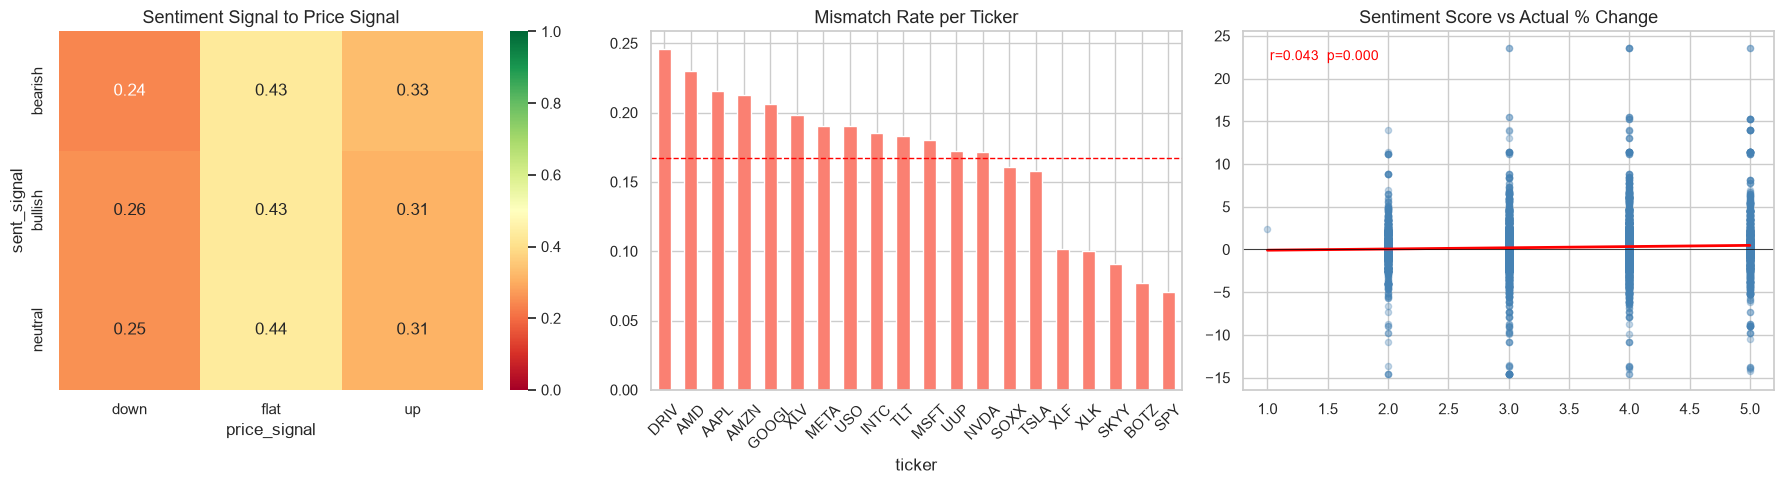


--- Confusion Matrix (counts) ---


price_signal,down,flat,up,Total
sent_signal,,,,
bearish,265,481,366,1112
bullish,912,1528,1104,3544
neutral,679,1163,824,2666
Total,1856,3172,2294,7322


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\mismatch_confusion_matrix.csv

--- Mismatch Rate per Ticker ---


,mismatch_rate,mismatch_pct,flag
ticker,,,
DRIV,0.246154,24.6,OK
AMD,0.230263,23.0,OK
AAPL,0.215781,21.6,OK
AMZN,0.212714,21.3,OK
GOOGL,0.206019,20.6,OK
XLV,0.198582,19.9,OK
META,0.190530,19.1,OK
USO,0.190476,19.0,OK
INTC,0.185567,18.6,OK


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\mismatch_rate_per_ticker.csv

Overall mismatch rate: 17.5%
Pearson r: 0.043  p=0.0002  significant


In [7]:
labeled = df.dropna(subset=['sentiment','bucket_1d']).copy()
labeled['sentiment']    = labeled['sentiment'].astype(int)
labeled['sent_signal']  = labeled['sentiment'].apply(
    lambda x: 'bullish' if x>=4 else ('bearish' if x<=2 else 'neutral'))
labeled['price_signal'] = labeled['bucket_1d'].apply(
    lambda x: 'up' if x in ('up','strong_up') else ('down' if x in ('down','strong_down') else 'flat'))
labeled['mismatch']     = (
    ((labeled['sent_signal']=='bullish') & (labeled['price_signal']=='down')) |
    ((labeled['sent_signal']=='bearish') & (labeled['price_signal']=='up'))
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = pd.crosstab(labeled['sent_signal'], labeled['price_signal'], normalize='index')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Sentiment Signal to Price Signal')
mismatch_rate = labeled.groupby('ticker')['mismatch'].mean().sort_values(ascending=False)
mismatch_rate.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].axhline(mismatch_rate.mean(), color='red', linestyle='--', linewidth=1)
axes[1].set_title('Mismatch Rate per Ticker')
axes[1].tick_params(axis='x', rotation=45)
sample = labeled.dropna(subset=['change_1d'])
axes[2].scatter(sample['sentiment'], sample['change_1d'], alpha=0.3, s=20, color='steelblue')
z = np.polyfit(sample['sentiment'], sample['change_1d'], 1)
xs = np.linspace(1, 5, 100)
axes[2].plot(xs, np.poly1d(z)(xs), color='red', linewidth=2)
axes[2].axhline(0, color='black', linewidth=0.5)
r, p_val = stats.pearsonr(sample['sentiment'], sample['change_1d'])
axes[2].annotate(f'r={r:.3f}  p={p_val:.3f}', xy=(0.05,0.92),
                 xycoords='axes fraction', fontsize=10,
                 color='red' if p_val<0.05 else 'grey')
axes[2].set_title('Sentiment Score vs Actual % Change')
plt.tight_layout(); plt.show()

# Tables
cm_counts = pd.crosstab(labeled['sent_signal'], labeled['price_signal'],
                        margins=True, margins_name='Total')
print('\n--- Confusion Matrix (counts) ---')
display(cm_counts)
save_csv(cm_counts, 'mismatch_confusion_matrix.csv')

mismatch_table = mismatch_rate.rename('mismatch_rate').to_frame()
mismatch_table['mismatch_pct'] = (mismatch_table['mismatch_rate']*100).round(1)
mismatch_table['flag'] = mismatch_table['mismatch_rate'].apply(
    lambda x: 'HIGH' if x>0.4 else 'OK')
print('\n--- Mismatch Rate per Ticker ---')
display(mismatch_table)
save_csv(mismatch_table, 'mismatch_rate_per_ticker.csv')

print(f'\nOverall mismatch rate: {labeled["mismatch"].mean()*100:.1f}%')
print(f'Pearson r: {r:.3f}  p={p_val:.4f}  {"significant" if p_val<0.05 else "not significant yet"}')

## 5 — Edge Cases

In [8]:
mismatches  = labeled[labeled['mismatch']].copy()
edge_cols   = ['date','ticker','sentiment','sent_signal','bucket_1d',
                'price_signal','change_1d','magnitude','summary','url']
edge_table  = mismatches[edge_cols].copy()
edge_table['date'] = edge_table['date'].dt.strftime('%Y-%m-%d')

print(f'Total mismatches: {len(edge_table)}')
print('\n--- Bullish Sentiment but Price Dropped (worst 10) ---')
display(edge_table[edge_table['sent_signal']=='bullish'].sort_values('change_1d').head(10))
print('\n--- Bearish Sentiment but Price Rose (top 10) ---')
display(edge_table[edge_table['sent_signal']=='bearish'].sort_values('change_1d', ascending=False).head(10))
save_csv(edge_table.set_index('url'), 'edge_cases.csv')

Total mismatches: 1278

--- Bullish Sentiment but Price Dropped (worst 10) ---


,date,ticker,sentiment,sent_signal,bucket_1d,price_signal,change_1d,magnitude,summary,url
13858,2026-07-22,TSLA,4,bullish,strong_down,down,-14.5237,large,Tesla's Q1 2026 delivered a 14.14% earnings be...,https://finance.yahoo.com/markets/stocks/artic...
13865,2026-07-22,TSLA,4,bullish,strong_down,down,-14.5237,large,"Double Down alerts issued for Tesla, suggestin...",https://finance.yahoo.com/markets/stocks/artic...
14323,2026-07-28,AMD,5,bullish,strong_down,down,-14.1954,large,South Korea's partnership with AMD to develop ...,https://www.upi.com/Top_News/World-News/2026/0...
14170,2026-07-27,AMD,4,bullish,strong_down,down,-13.9388,large,AMD's MI455X targets AI data centers with fast...,https://www.techradar.com/pro/amd-says-the-mi4...
14165,2026-07-27,AMD,5,bullish,strong_down,down,-13.9388,large,AMD's Venice 256-core CPU targets a Q4 2026 la...,https://www.techradar.com/pro/amds-venice-is-t...
14337,2026-07-28,AMD,5,bullish,strong_down,down,-13.9024,large,"AMD claimed outright leadership across CPUs, G...",https://siliconangle.com/2026/07/27/amd-calls-...
14325,2026-07-28,AMD,4,bullish,strong_down,down,-13.7974,large,Core Scientific's shift to AI infrastructure a...,https://www.benzinga.com/trading-ideas/movers/...
14279,2026-07-28,AMD,5,bullish,strong_down,down,-13.7590,large,AMD is the top pick to become the next trillio...,https://www.benzinga.com/Opinion/26/07/6072914...
14209,2026-07-27,AMD,4,bullish,strong_down,down,-13.7024,large,Foundation Future Industries will use AMD chip...,https://finance.yahoo.com/technology/ai/articl...
14193,2026-07-27,AMD,5,bullish,strong_down,down,-13.7024,large,AMD's strategic partnership with Anthropic and...,https://finance.yahoo.com/technology/ai/articl...



--- Bearish Sentiment but Price Rose (top 10) ---


,date,ticker,sentiment,sent_signal,bucket_1d,price_signal,change_1d,magnitude,summary,url
7163,2026-05-07,INTC,2,bearish,strong_up,up,13.9573,large,Apple explored using Intel and Samsung for pro...,https://www.thehindu.com/sci-tech/technology/a...
7269,2026-05-07,AMD,2,bearish,strong_up,up,11.4405,large,AMD's gaming revenue is expected to decline by...,https://www.techradar.com/computing/computing-...
2560,2026-04-01,USO,2,bearish,strong_up,up,11.1451,large,Brent crude oil prices surge amid ongoing war ...,https://www.thehindu.com/business/markets/stoc...
2651,2026-04-01,USO,2,bearish,strong_up,up,11.1451,large,The article discusses the impact of rising cru...,https://www.livemint.com/market/stock-market-n...
2678,2026-04-01,USO,2,bearish,strong_up,up,11.1451,large,Indian stock markets remain volatile due to ge...,https://www.livemint.com/market/stock-market-n...
2674,2026-04-01,USO,2,bearish,strong_up,up,11.1451,large,The Indian stock market benchmark indices are ...,https://www.livemint.com/market/stock-market-n...
2567,2026-04-01,USO,2,bearish,strong_up,up,11.1451,large,Crude oil prices surge due to ongoing war in W...,https://www.thehindu.com/business/markets/stoc...
2392,2026-03-31,INTC,2,bearish,strong_up,up,8.8375,large,Intel's valuation has surged to imply meaningf...,https://www.benzinga.com/trading-ideas/movers/...
12204,2026-06-30,META,2,bearish,strong_up,up,8.8090,large,Facebook and Instagram addictive design lawsui...,https://www.yahoo.com/news/articles/meta-loses...
12268,2026-06-30,META,2,bearish,strong_up,up,8.8090,large,Meta Platforms' shares are down 30% from last ...,https://finance.yahoo.com/markets/stocks/artic...


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\edge_cases.csv


## 6 — Stock vs Benchmark Correlation

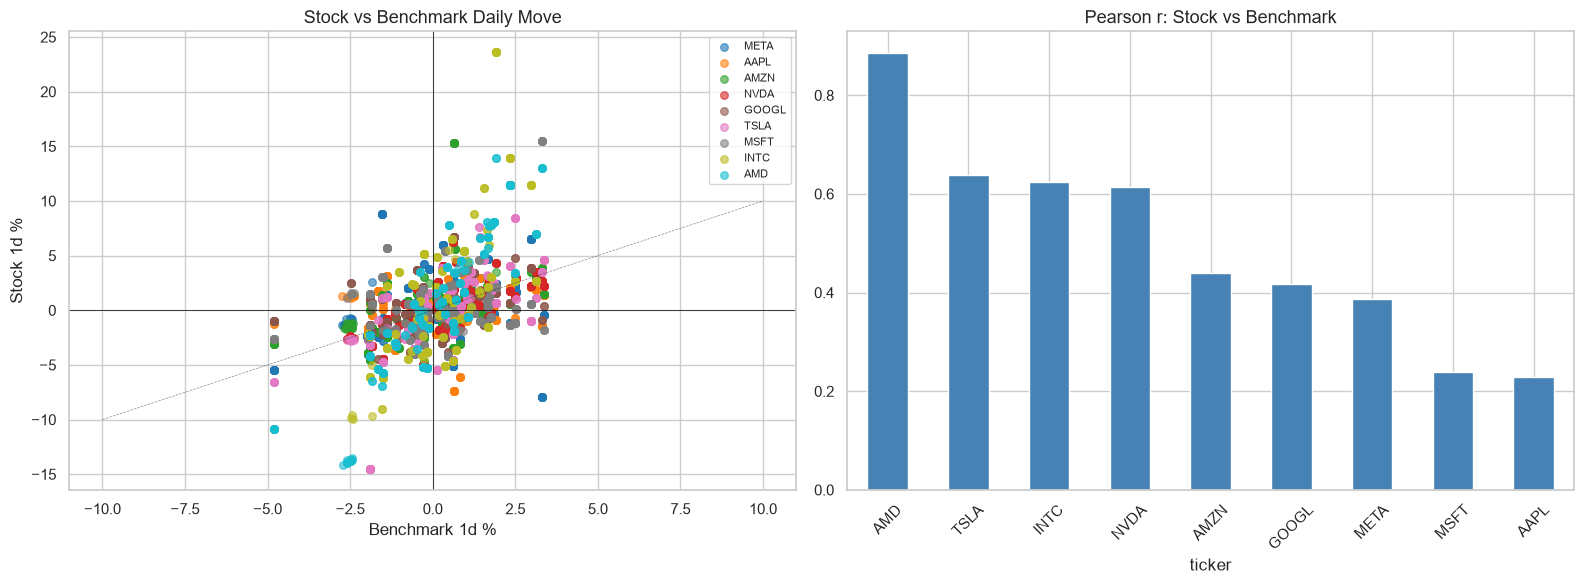


--- Stock vs Benchmark Correlation ---


,benchmark,r,p,n
ticker,,,,
AMD,QQQ,0.885,0.0,304
TSLA,QQQ,0.639,0.0,399
INTC,QQQ,0.624,0.0,291
NVDA,QQQ,0.614,0.0,863
AMZN,QQQ,0.440,0.0,409
GOOGL,QQQ,0.417,0.0,432
META,QQQ,0.386,0.0,887
MSFT,QQQ,0.239,0.0,556
AAPL,QQQ,0.228,0.0,621


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\correlations_stock_vs_benchmark.csv


In [9]:
company_df = df[df['category']=='company'].dropna(subset=['change_1d','bm_change_1d']).copy()
if company_df.empty:
    print('No data yet')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    tickers = company_df['ticker'].unique()
    colors  = plt.cm.tab10(np.linspace(0, 1, len(tickers)))
    for ticker, color in zip(tickers, colors):
        sub = company_df[company_df['ticker']==ticker]
        axes[0].scatter(sub['bm_change_1d'], sub['change_1d'],
                        label=ticker, alpha=0.6, s=30, color=color)
    axes[0].axhline(0, color='black', linewidth=0.5)
    axes[0].axvline(0, color='black', linewidth=0.5)
    axes[0].plot([-10,10],[-10,10],'k--',linewidth=0.5,alpha=0.5)
    axes[0].set_xlabel('Benchmark 1d %'); axes[0].set_ylabel('Stock 1d %')
    axes[0].set_title('Stock vs Benchmark Daily Move')
    axes[0].legend(bbox_to_anchor=(1,1), fontsize=8)
    corrs = []
    for ticker in tickers:
        sub = company_df[company_df['ticker']==ticker]
        if len(sub) > 5:
            r, p = stats.pearsonr(sub['bm_change_1d'], sub['change_1d'])
            corrs.append({'ticker': ticker, 'benchmark': sub['benchmark'].iloc[0],
                          'r': round(r,3), 'p': round(p,4), 'n': len(sub)})
    corr_df = pd.DataFrame(corrs).set_index('ticker').sort_values('r', ascending=False)
    corr_df['r'].plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Pearson r: Stock vs Benchmark')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()
    print('\n--- Stock vs Benchmark Correlation ---')
    display(corr_df)
    save_csv(corr_df, 'correlations_stock_vs_benchmark.csv')

## 7 — Macro Impact on Stocks

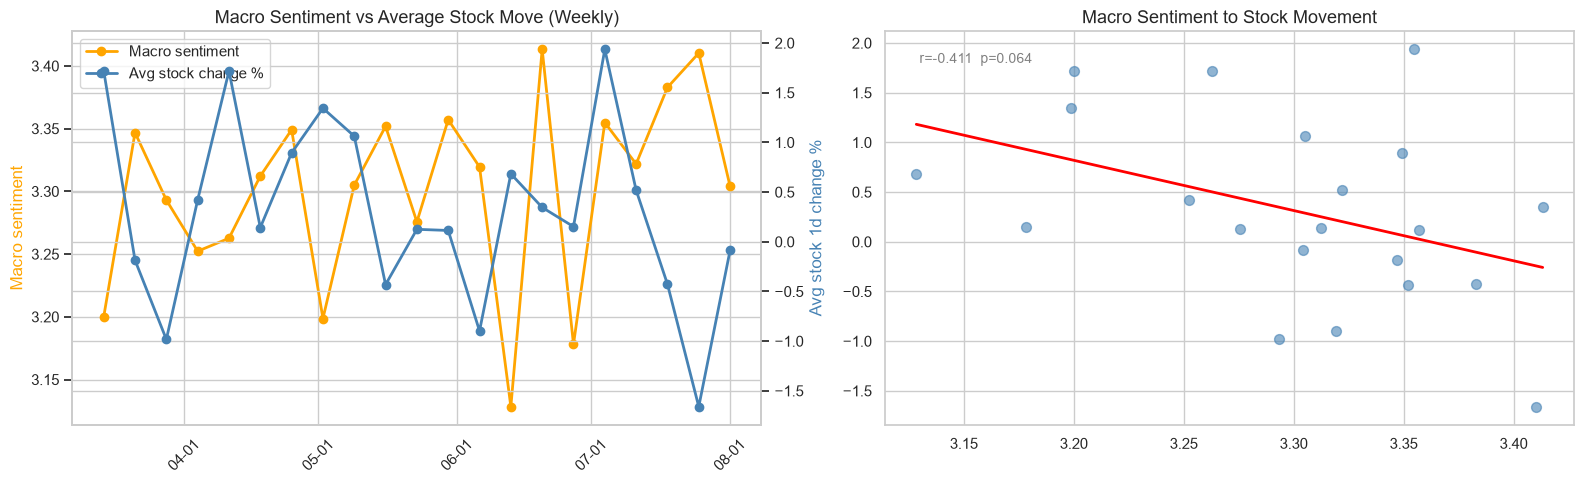


--- Weekly Macro Sentiment vs Avg Stock Change ---


,week_end,macro_sentiment,avg_stock_change,macro_signal
0,2026-03-14 (Sat),3.2000,1.7207,neutral
1,2026-03-21 (Sat),3.3468,-0.1860,neutral
2,2026-03-28 (Sat),3.2931,-0.9826,neutral
3,2026-04-04 (Sat),3.2523,0.4207,neutral
4,2026-04-11 (Sat),3.2626,1.7181,neutral
5,2026-04-18 (Sat),3.3122,0.1431,neutral
6,2026-04-25 (Sat),3.3492,0.8946,neutral
7,2026-05-02 (Sat),3.1986,1.3439,neutral
8,2026-05-09 (Sat),3.3050,1.0625,neutral
9,2026-05-16 (Sat),3.3519,-0.4314,neutral


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\macro_vs_stocks.csv


In [10]:
macro_df    = df[df['category']=='sector/macro'].dropna(subset=['sentiment','date']).copy()
company_df2 = df[df['category']=='company'].dropna(subset=['change_1d','date']).copy()
if macro_df.empty or company_df2.empty:
    print('Not enough data yet')
else:
    # Convert to weekly (ending Saturday)
    weekly_macro  = macro_df.set_index('date').resample('W-SAT')['sentiment'].mean().reset_index()
    weekly_macro.columns  = ['date','macro_sentiment']
    weekly_stocks = company_df2.set_index('date').resample('W-SAT')['change_1d'].mean().reset_index()
    weekly_stocks.columns = ['date','avg_stock_change']
    merged = weekly_macro.merge(weekly_stocks, on='date')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    ax2 = axes[0].twinx()
    axes[0].plot(merged['date'], merged['macro_sentiment'], color='orange', linewidth=2, label='Macro sentiment', marker='o')
    ax2.plot(merged['date'], merged['avg_stock_change'], color='steelblue', linewidth=2, label='Avg stock change %', marker='o')
    axes[0].set_ylabel('Macro sentiment', color='orange')
    ax2.set_ylabel('Avg stock 1d change %', color='steelblue')
    axes[0].set_title('Macro Sentiment vs Average Stock Move (Weekly)')
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
    l1,lab1 = axes[0].get_legend_handles_labels()
    l2,lab2 = ax2.get_legend_handles_labels()
    axes[0].legend(l1+l2, lab1+lab2, loc='upper left')
    axes[1].scatter(merged['macro_sentiment'], merged['avg_stock_change'], alpha=0.6, s=50, color='steelblue')
    if len(merged) > 3:
        z = np.polyfit(merged['macro_sentiment'], merged['avg_stock_change'], 1)
        xs = np.linspace(merged['macro_sentiment'].min(), merged['macro_sentiment'].max(), 100)
        axes[1].plot(xs, np.poly1d(z)(xs), color='red', linewidth=2)
        r, p_val = stats.pearsonr(merged['macro_sentiment'], merged['avg_stock_change'])
        axes[1].annotate(f'r={r:.3f}  p={p_val:.3f}', xy=(0.05,0.92),
                         xycoords='axes fraction', fontsize=10,
                         color='red' if p_val<0.05 else 'grey')
    axes[1].set_title('Macro Sentiment to Stock Movement')
    plt.tight_layout(); plt.show()

    macro_table = merged.copy()
    macro_table['week_end'] = macro_table['date'].dt.strftime('%Y-%m-%d (Sat)')
    macro_table = macro_table.round(4)
    macro_table['macro_signal'] = macro_table['macro_sentiment'].apply(
        lambda x: 'bullish' if x>=4 else ('bearish' if x<=2 else 'neutral'))
    print('\n--- Weekly Macro Sentiment vs Avg Stock Change ---')
    display(macro_table[['week_end','macro_sentiment','avg_stock_change','macro_signal']])
    save_csv(macro_table.set_index('week_end'), 'macro_vs_stocks.csv')

## 8 — Sector Sentiment vs Constituent Stock Performance

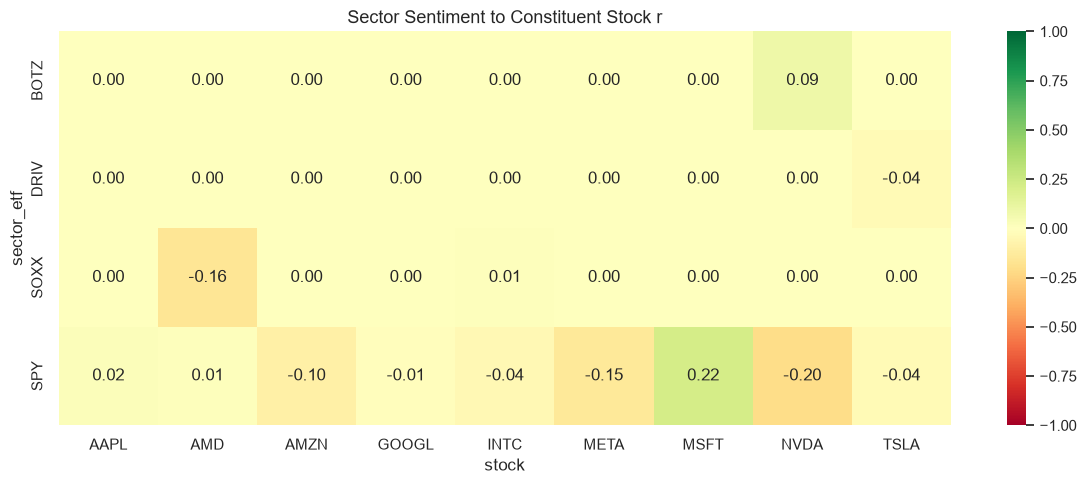


--- Sector Sentiment to Stock Correlation ---


,sector_etf,sector_name,stock,r,p,n_days,significant
7,SPY,S&P500,MSFT,0.218,0.0704,70,No
3,BOTZ,AI/Robotics,NVDA,0.087,0.6467,30,No
6,SPY,S&P500,AAPL,0.020,0.8699,70,No
13,SPY,S&P500,AMD,0.015,0.9160,55,No
1,SOXX,Semiconductor,INTC,0.012,0.9306,52,No
0,SOXX,Semiconductor,NVDA,0.004,0.9720,64,No
11,SPY,S&P500,GOOGL,-0.010,0.9333,66,No
9,SPY,S&P500,TSLA,-0.038,0.7574,69,No
4,DRIV,EV,TSLA,-0.038,0.7830,56,No
12,SPY,S&P500,INTC,-0.042,0.7373,65,No


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\correlations_sector_vs_stocks.csv


In [11]:
SECTOR_STOCKS = {
    'QQQ':  ['NVDA','AAPL','MSFT','META','TSLA','AMZN','GOOGL','INTC','AMD'],
    'SOXX': ['NVDA','INTC','AMD'],
    'BOTZ': ['NVDA'],
    'DRIV': ['TSLA'],
    'SPY':  ['NVDA','AAPL','MSFT','META','TSLA','AMZN','GOOGL','INTC','AMD'],
}
sector_df   = df[df['category']=='sector/macro'].dropna(subset=['sentiment','date']).copy()
company_df3 = df[df['category']=='company'].dropna(subset=['change_1d','date']).copy()
results = []
for sector_ticker, stock_tickers in SECTOR_STOCKS.items():
    sector_news = sector_df[sector_df['ticker']==sector_ticker]
    if sector_news.empty: continue
    daily_sector = sector_news.groupby('date')['sentiment'].mean()
    for stock in stock_tickers:
        stock_prices = company_df3[company_df3['ticker']==stock]
        if stock_prices.empty: continue
        daily_stock = stock_prices.groupby('date')['change_1d'].mean()
        merged = daily_sector.rename('sector_sent').reset_index() \
            .merge(daily_stock.rename('stock_chg').reset_index(), on='date')
        if len(merged) < 5: continue
        r, p_val = stats.pearsonr(merged['sector_sent'], merged['stock_chg'])
        results.append({'sector_etf': sector_ticker,
                        'sector_name': ETF_LABELS.get(sector_ticker, sector_ticker),
                        'stock': stock, 'r': round(r,3), 'p': round(p_val,4),
                        'n_days': len(merged),
                        'significant': 'Yes' if p_val<0.05 else 'No'})
if results:
    res_df  = pd.DataFrame(results)
    pivot_r = res_df.pivot_table(index='sector_etf', columns='stock', values='r', fill_value=0)
    plt.figure(figsize=(12, 5))
    sns.heatmap(pivot_r, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1)
    plt.title('Sector Sentiment to Constituent Stock r')
    plt.tight_layout(); plt.show()
    print('\n--- Sector Sentiment to Stock Correlation ---')
    display(res_df.sort_values('r', ascending=False))
    save_csv(res_df.set_index(['sector_etf','stock']), 'correlations_sector_vs_stocks.csv')
else:
    print('Not enough overlapping dates yet')

## 9 — Does Sentiment Predict Price Better in High- or Low-Volatility Regimes?

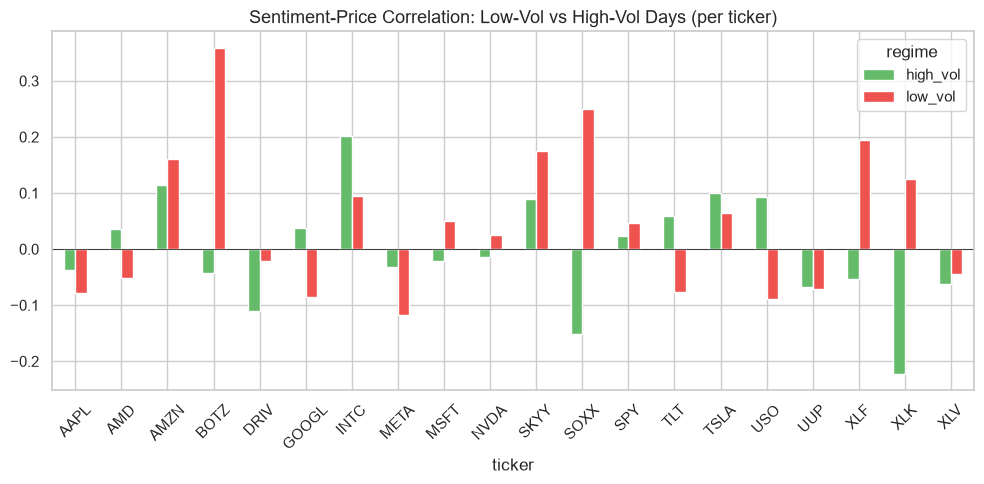


--- Sentiment predictive power by volatility regime ---


,ticker,regime,r,p,n
1,AAPL,high_vol,-0.037,0.5134,314
0,AAPL,low_vol,-0.079,0.1711,304
3,AMD,high_vol,0.036,0.6498,160
2,AMD,low_vol,-0.051,0.5404,144
5,AMZN,high_vol,0.115,0.0985,208
4,AMZN,low_vol,0.160,0.0234,201
7,BOTZ,high_vol,-0.043,0.8588,20
6,BOTZ,low_vol,0.359,0.1314,19
9,DRIV,high_vol,-0.111,0.3670,68
8,DRIV,low_vol,-0.022,0.8630,62


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\correlations_volatility_regime.csv

Avg r (low-vol days):  0.045
Avg r (high-vol days): -0.003
If high-vol r is meaningfully stronger, sentiment carries more signal on days the stock is already moving a lot — worth weighting those rows higher in training, or treating quiet-day flat predictions as a separate, easier sub-problem.


In [12]:
vol_df = df.dropna(subset=['sentiment','change_1d','trailing_vol_pct']).copy()
if len(vol_df) < 30:
    print('Not enough data yet')
else:
    # Median split per ticker (not globally) so we compare each ticker's own
    # quiet days vs its own volatile days, rather than mixing tickers of
    # very different baseline volatility into one global split.
    vol_df['vol_regime'] = vol_df.groupby('ticker')['trailing_vol_pct'] \
        .transform(lambda x: np.where(x >= x.median(), 'high_vol', 'low_vol'))

    results = []
    for ticker, sub in vol_df.groupby('ticker'):
        for regime in ['low_vol', 'high_vol']:
            rsub = sub[sub['vol_regime'] == regime]
            if len(rsub) < 8:
                continue
            r, p = stats.pearsonr(rsub['sentiment'], rsub['change_1d'])
            results.append({'ticker': ticker, 'regime': regime, 'r': round(r,3),
                            'p': round(p,4), 'n': len(rsub)})

    if results:
        regime_df = pd.DataFrame(results)
        pivot = regime_df.pivot_table(index='ticker', columns='regime', values='r')

        fig, ax = plt.subplots(figsize=(10,5))
        pivot.plot(kind='bar', ax=ax, color=['#66bb6a','#ef5350'])
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_title('Sentiment-Price Correlation: Low-Vol vs High-Vol Days (per ticker)')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout(); plt.show()

        print('\n--- Sentiment predictive power by volatility regime ---')
        display(regime_df.sort_values(['ticker','regime']))
        save_csv(regime_df.set_index(['ticker','regime']), 'correlations_volatility_regime.csv')

        overall_low  = regime_df[regime_df['regime']=='low_vol']['r'].mean()
        overall_high = regime_df[regime_df['regime']=='high_vol']['r'].mean()
        print(f'\nAvg r (low-vol days):  {overall_low:.3f}')
        print(f'Avg r (high-vol days): {overall_high:.3f}')
        print('If high-vol r is meaningfully stronger, sentiment carries more signal '
              'on days the stock is already moving a lot — worth weighting those rows '
              'higher in training, or treating quiet-day flat predictions as a separate, '
              'easier sub-problem.')
    else:
        print('Not enough per-ticker/regime samples yet')

## 10 — Does Article Relevance Predict Signal Strength?

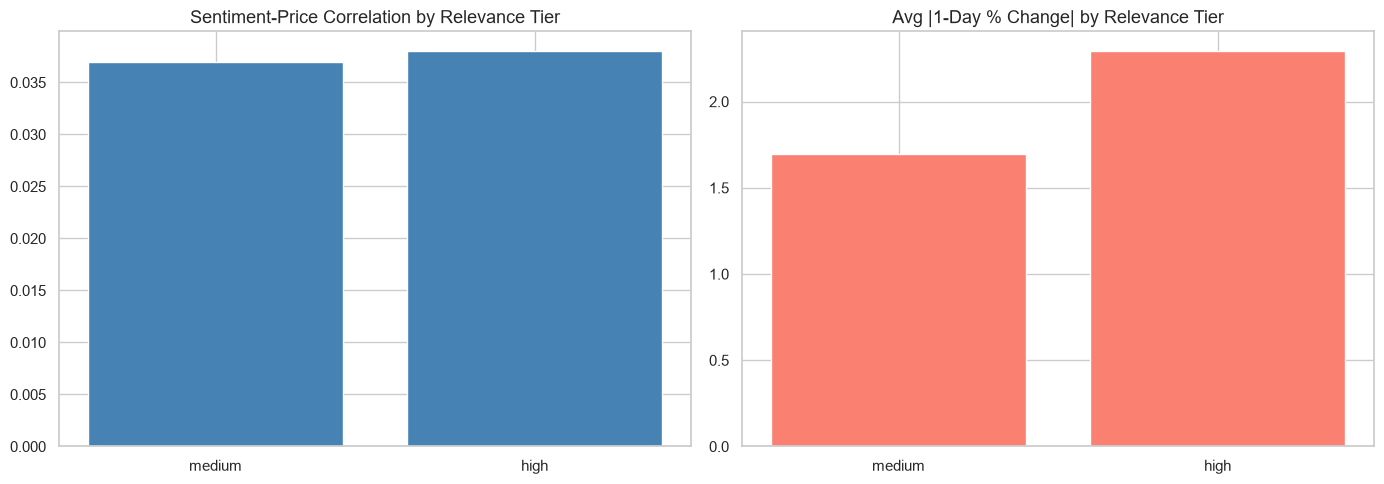


--- Signal strength by relevance tier ---


,relevance,n,r,p,avg_abs_change_1d,significant
0,medium,5427.0,0.037,0.0066,1.698,Yes
1,high,1895.0,0.038,0.1019,2.292,No


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\correlations_relevance_tier.csv

If r and avg |change_1d| both increase from low -> high relevance, the relevance field is doing real work and low-relevance rows are likely diluting training signal — worth filtering relevance==1 (already done above) and possibly relevance==2 as well if this shows a big gap between medium and high.


In [13]:
rel_df = df.dropna(subset=['sentiment','change_1d','relevance']).copy()
if len(rel_df) < 30:
    print('Not enough data yet')
else:
    rel_labels = {1: 'low', 2: 'medium', 3: 'high'}
    rel_df['relevance_label'] = rel_df['relevance'].map(rel_labels).fillna('unknown')

    results = []
    for rel_level, sub in rel_df.groupby('relevance_label'):
        if len(sub) < 8:
            continue
        r, p = stats.pearsonr(sub['sentiment'], sub['change_1d'])
        results.append({
            'relevance': rel_level, 'n': len(sub), 'r': round(r,3), 'p': round(p,4),
            'avg_abs_change_1d': round(sub['change_1d'].abs().mean(), 3),
            'significant': 'Yes' if p < 0.05 else 'No',
        })

    if results:
        rel_result_df = pd.DataFrame(results).set_index('relevance') \
            .reindex(['low','medium','high']).dropna(how='all').reset_index()

        fig, axes = plt.subplots(1, 2, figsize=(14,5))
        axes[0].bar(rel_result_df['relevance'], rel_result_df['r'], color='steelblue')
        axes[0].axhline(0, color='black', linewidth=0.5)
        axes[0].set_title('Sentiment-Price Correlation by Relevance Tier')
        axes[1].bar(rel_result_df['relevance'], rel_result_df['avg_abs_change_1d'], color='salmon')
        axes[1].set_title('Avg |1-Day % Change| by Relevance Tier')
        plt.tight_layout(); plt.show()

        print('\n--- Signal strength by relevance tier ---')
        display(rel_result_df)
        save_csv(rel_result_df.set_index('relevance'), 'correlations_relevance_tier.csv')

        print('\nIf r and avg |change_1d| both increase from low -> high relevance, the '
              'relevance field is doing real work and low-relevance rows are likely diluting '
              'training signal — worth filtering relevance==1 (already done above) and possibly '
              'relevance==2 as well if this shows a big gap between medium and high.')
    else:
        print('Not enough samples per relevance tier yet')

## 11 — Dataset Readiness Summary

In [14]:
labeled = df.dropna(subset=['sentiment','bucket_1d'])
bucket_order = ['strong_down','down','flat','up','strong_up']

def normalized_entropy(series, categories=bucket_order):
    """Shannon entropy of the bucket distribution, normalized to [0,1].
    1.0 = perfectly uniform across all 5 buckets (ideal for classification).
    0.0 = all articles fall in a single bucket (unusable — model just
    learns to predict that one class).
    This is a more complete readiness signal than flat_pct alone: a ticker
    could have flat_pct=40% and still be badly imbalanced if the remaining
    60% is entirely strong_up with none in down/strong_down.
    """
    counts = series.value_counts().reindex(categories, fill_value=0)
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    if len(probs) <= 1:
        return 0.0
    ent = -(probs * np.log(probs)).sum()
    max_ent = np.log(len(categories))
    return round(ent / max_ent, 3)

ticker_ready = labeled.groupby(['ticker','category']).agg(
    total_articles     = ('url',              'count'),
    unique_days        = ('date',             'nunique'),
    avg_sentiment      = ('sentiment',        'mean'),
    avg_trailing_vol   = ('trailing_vol_pct', 'mean'),
    flat_pct           = ('bucket_1d', lambda x: round((x=='flat').mean()*100,1)),
    strong_down_pct    = ('bucket_1d', lambda x: round((x=='strong_down').mean()*100,1)),
    strong_up_pct      = ('bucket_1d', lambda x: round((x=='strong_up').mean()*100,1)),
    bucket_entropy     = ('bucket_1d', normalized_entropy),
).round(2).reset_index()

# Balance flag now considers both flat dominance AND overall distribution
# shape via entropy, since those can disagree (see docstring above).
ticker_ready['imbalance_flag'] = ticker_ready.apply(
    lambda row: 'HIGH FLAT' if row['flat_pct'] > 70
                else ('LOW ENTROPY' if row['bucket_entropy'] < 0.5 else 'OK'),
    axis=1
)
ticker_ready['readiness'] = ticker_ready['total_articles'].apply(
    lambda x: 'LOW <50' if x<50 else ('MED 50-200' if x<200 else 'READY 200+'))

total_examples = int(ticker_ready['total_articles'].sum())
total_ticker_groups = int(ticker_ready[['ticker','category']].drop_duplicates().shape[0])
ready_tickers = int((ticker_ready['readiness'] == 'READY 200+').sum())
medium_tickers = int((ticker_ready['readiness'] == 'MED 50-200').sum())
low_tickers = int((ticker_ready['readiness'] == 'LOW <50').sum())
high_flat_tickers = ticker_ready[ticker_ready['flat_pct'] > 70]['ticker'].unique().tolist()
low_entropy_tickers = ticker_ready[ticker_ready['bucket_entropy'] < 0.5]['ticker'].unique().tolist()
low_sample_tickers = ticker_ready[ticker_ready['total_articles'] < 50]['ticker'].unique().tolist()
overall_flat_pct = float(bucket_table.loc['flat','pct']) if 'flat' in bucket_table.index else None
overall_entropy = normalized_entropy(labeled['bucket_1d'])
neutral_sentiment_pct = float(sent_table.loc[3,'pct']) if 3 in sent_table.index else None
dataset_mismatch_pct = float(mismatch_table['mismatch_pct'].mean()) if 'mismatch_pct' in mismatch_table.columns else None

readiness_flag = (
    total_examples >= 2000 and
    overall_flat_pct is not None and overall_flat_pct <= 50 and
    overall_entropy >= 0.6 and
    len(high_flat_tickers) <= 5 and
    len(low_sample_tickers) <= 10 and
    ready_tickers >= 3
)

summary = {
    'total_examples': total_examples,
    'total_ticker_groups': total_ticker_groups,
    'ready_tickers': ready_tickers,
    'medium_tickers': medium_tickers,
    'low_tickers': low_tickers,
    'high_flat_tickers': len(high_flat_tickers),
    'low_entropy_tickers': len(low_entropy_tickers),
    'low_sample_tickers': len(low_sample_tickers),
    'overall_flat_pct': overall_flat_pct,
    'overall_bucket_entropy': overall_entropy,
    'neutral_sentiment_pct': neutral_sentiment_pct,
    'dataset_mismatch_pct': dataset_mismatch_pct,
    'ready_to_train': bool(readiness_flag),
    'recommendation': (
        'Proceed with fine-tuning' if readiness_flag else 'Collect more data, reduce flat labels, or improve ticker coverage'
    ),
}

print('='*60)
print('DATASET READINESS SUMMARY')
print('='*60)
print(f'Total articles:      {total_examples:>6,}')
print(f'Total ticker groups: {total_ticker_groups}')
print(f'Ready tickers:       {ready_tickers}')
print(f'Medium tickers:      {medium_tickers}')
print(f'Low sample tickers:  {low_tickers}')
print(f'High-flat tickers:   {len(high_flat_tickers)}')
print(f'Low-entropy tickers: {len(low_entropy_tickers)}')
print(f'Overall flat pct:    {overall_flat_pct}')
print(f'Overall entropy:     {overall_entropy}  (1.0 = perfectly balanced across 5 buckets)')
print(f'Neutral sentiment:   {neutral_sentiment_pct}')
print(f'Average mismatch:    {dataset_mismatch_pct}')
print(f"Ready to train:      {summary['ready_to_train']}")
print()
display(ticker_ready.sort_values('bucket_entropy', ascending=False))
save_csv(ticker_ready.set_index('ticker'), 'dataset_readiness.csv')

summary_df = pd.DataFrame([summary])
save_csv(summary_df, 'dataset_readiness_summary.csv')
with open(os.path.join(ANALYSIS_DIR, 'dataset_readiness_metrics.json'), 'w', encoding='utf-8') as fh:
    json.dump(summary, fh, ensure_ascii=False, indent=2)

print(f"Saved readiness summary to {os.path.join(ANALYSIS_DIR, 'dataset_readiness_summary.csv')}")
print(f"Saved readiness metrics to {os.path.join(ANALYSIS_DIR, 'dataset_readiness_metrics.json')}")

DATASET READINESS SUMMARY
Total articles:       7,322
Total ticker groups: 20
Ready tickers:       15
Medium tickers:      3
Low sample tickers:  2
High-flat tickers:   0
Low-entropy tickers: 0
Overall flat pct:    43.3
Overall entropy:     0.87  (1.0 = perfectly balanced across 5 buckets)
Neutral sentiment:   37.2
Average mismatch:    16.715
Ready to train:      True



,ticker,category,total_articles,unique_days,avg_sentiment,avg_trailing_vol,flat_pct,strong_down_pct,strong_up_pct,bucket_entropy,imbalance_flag,readiness
0,AAPL,company,621,80,3.52,1.54,32.0,7.9,11.3,0.93,OK,READY 200+
13,TLT,sector/macro,284,65,3.19,0.58,32.0,10.9,7.0,0.92,OK,READY 200+
2,AMZN,company,409,83,3.75,1.86,39.4,10.8,9.5,0.91,OK,READY 200+
1,AMD,company,304,63,4.08,5.13,40.8,7.2,17.1,0.91,OK,READY 200+
15,USO,sector/macro,315,70,3.60,4.23,25.4,9.8,8.9,0.91,OK,READY 200+
11,SOXX,sector/macro,280,76,3.71,2.99,34.3,5.7,16.1,0.91,OK,READY 200+
4,DRIV,sector/macro,130,58,3.58,2.17,35.4,6.2,9.2,0.90,OK,MED 50-200
8,MSFT,company,556,80,3.41,1.91,42.3,7.4,9.4,0.88,OK,READY 200+
14,TSLA,company,399,78,3.20,3.06,45.6,10.5,10.0,0.88,OK,READY 200+
10,SKYY,sector/macro,198,65,3.43,2.11,39.9,4.0,17.2,0.87,OK,MED 50-200


  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\dataset_readiness.csv
  Saved: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\dataset_readiness_summary.csv
Saved readiness summary to C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\dataset_readiness_summary.csv
Saved readiness metrics to C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\dataset_readiness_metrics.json


## 12 — Consolidated Insights Export (Single File for AI Analysis)

In [15]:
from datetime import datetime as _dt

def df_to_md(d, max_rows=None):
    """Render a DataFrame as a markdown table without needing the optional
    `tabulate` dependency that pandas.DataFrame.to_markdown() requires."""
    d = d.reset_index() if d.index.name is not None else d.copy()
    if max_rows is not None:
        d = d.head(max_rows)
    cols = list(d.columns)
    lines = ['| ' + ' | '.join(str(c) for c in cols) + ' |']
    lines.append('|' + '|'.join(['---'] * len(cols)) + '|')
    for _, row in d.iterrows():
        lines.append('| ' + ' | '.join(str(row[c]) for c in cols) + ' |')
    return '\n'.join(lines)

sections = []
sections.append("# FinCast Dataset Analysis — Consolidated Insights\n")
sections.append(f"_Generated: {_dt.now().strftime('%Y-%m-%d %H:%M')}_\n")

sections.append("## Dataset Overview")
sections.append(f"- Total articles: {len(df):,}")
sections.append(f"- Date range: {df['date'].min().date()} to {df['date'].max().date()}")
sections.append(f"- Unique tickers: {df['ticker'].nunique()}")
sections.append(f"- Articles with price data: {df['bucket_1d'].notna().sum():,}\n")

if 'bucket_table' in globals():
    sections.append("## 1. Overall Price Bucket Distribution")
    sections.append(df_to_md(bucket_table) + "\n")
if 'bucket_ticker' in globals():
    sections.append("## 1b. Price Bucket % per Ticker")
    sections.append(df_to_md(bucket_ticker) + "\n")
if 'mag_df' in globals():
    sections.append("## 1c. Move Magnitude Distribution")
    sections.append(df_to_md(mag_df) + "\n")

if 'cm_counts' in globals():
    sections.append("## 2. Sentiment vs Price — Confusion Matrix")
    sections.append(df_to_md(cm_counts) + "\n")
if 'mismatch_table' in globals():
    sections.append("## 2b. Mismatch Rate per Ticker")
    sections.append(df_to_md(mismatch_table) + "\n")
    if 'mismatch_overall_pct' in globals():
        sections.append(f"Overall mismatch rate: {mismatch_overall_pct}%")
        sections.append(f"Sentiment vs change_1d Pearson r={mismatch_pearson_r}, p={mismatch_pearson_p}\n")

# Edge cases: counts only, no verbatim article text — this is a data-quality
# signal (how often does sentiment disagree with price), not a reading list.
if 'edge_table' in globals():
    n_total = len(edge_table)
    n_bullish_down = (edge_table['sent_signal']=='bullish').sum()
    n_bearish_up   = (edge_table['sent_signal']=='bearish').sum()
    sections.append("## 3. Edge Cases — Sentiment/Price Mismatch Counts")
    sections.append(f"- Total mismatches: {n_total} ({n_total/len(labeled)*100:.1f}% of labeled articles)")
    sections.append(f"- Bullish sentiment but price dropped: {n_bullish_down}")
    sections.append(f"- Bearish sentiment but price rose: {n_bearish_up}")
    if n_total > 0:
        worst_mag = edge_table['change_1d'].abs().max()
        sections.append(f"- Largest mismatched move: {worst_mag:.2f}% (1-day change)")
    per_ticker_mismatch = edge_table['ticker'].value_counts()
    if len(per_ticker_mismatch) > 0:
        sections.append(f"- Tickers with most mismatches: " +
                        ", ".join(f"{t} ({c})" for t, c in per_ticker_mismatch.head(5).items()))
    sections.append("")

if 'corr_df' in globals():
    sections.append("## 4. Stock vs Benchmark Correlation")
    sections.append(df_to_md(corr_df) + "\n")

if 'macro_table' in globals():
    sections.append("## 5. Weekly Macro Sentiment vs Avg Stock Change")
    sections.append(df_to_md(macro_table[['week_end','macro_sentiment','avg_stock_change','macro_signal']]) + "\n")

if 'res_df' in globals():
    sections.append("## 6. Sector Sentiment vs Constituent Stock Correlation")
    sections.append(df_to_md(res_df.sort_values('r', ascending=False)) + "\n")

if 'regime_df' in globals():
    sections.append("## 7. Volatility Regime vs Sentiment Predictive Power")
    sections.append(df_to_md(regime_df.sort_values(['ticker','regime'])) + "\n")

if 'rel_result_df' in globals():
    sections.append("## 8. Relevance Tier vs Signal Strength")
    sections.append(df_to_md(rel_result_df) + "\n")

if 'ticker_ready' in globals():
    sections.append("## 9. Per-Ticker Readiness")
    sections.append(df_to_md(ticker_ready.sort_values('bucket_entropy', ascending=False)) + "\n")

if 'summary' in globals():
    sections.append("## 10. Overall Readiness Summary")
    for k, v in summary.items():
        sections.append(f"- **{k}**: {v}")
    sections.append("")

insights_md = "\n".join(sections)
out_path = os.path.join(ANALYSIS_DIR, 'fincast_dataset_insights.md')
with open(out_path, 'w', encoding='utf-8') as fh:
    fh.write(insights_md)

print(f"Saved consolidated insights to {out_path}")
print(f"File size: {len(insights_md):,} characters (~{len(insights_md)//4:,} tokens)")
print("Upload this single file to an AI assistant instead of the individual CSVs.")

Saved consolidated insights to C:\work\PratyushMishraGitHub\news_analysis\news_scraper\analysis\fincast_dataset_insights.md
File size: 10,230 characters (~2,557 tokens)
Upload this single file to an AI assistant instead of the individual CSVs.
